# Thresholding / Binarizing

```TEXT
Binarization
To a computer, an image is just a massive grid of pixels, each with a value ranging from 0 to 255. If we want our program to focus only on the text and ignore the background, we need a way to simplify the world. We need to turn everything into stark, unambiguous black and white.

In computer vision, this process is called binarization, and the primary tool we use to achieve it is thresholding.

Threshold
1. If a pixel's value is greater than the threshold, we flip it entirely to white (255).
2. If a pixel's value is less than or equal to the threshold, we flip it entirely to black (0).
Just like that, a complex grayscale image is reduced to a binary representation: 0 or 1, black or white. No in-between. No gray areas!

| Threshold Type | What it does |
|---|---|
| `cv2.THRESH_BINARY` | Over threshold → White; Under threshold → Black |
| `cv2.THRESH_BINARY_INV` | Over threshold → Black; Under threshold → White |
| `cv2.ADAPTIVE_THRESH_MEAN_C` | Threshold is the mean of the neighborhood area. |
| `cv2.ADAPTIVE_THRESH_GAUSSIAN_C` | Threshold is the weighted sum of the neighborhood area (more natural results). |

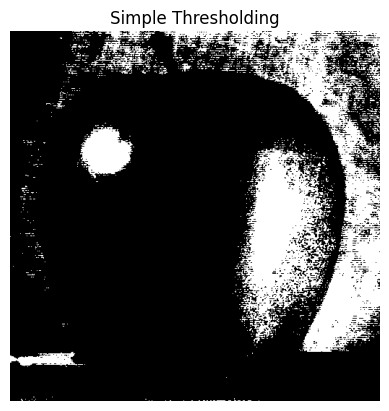

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


img=cv.imread("../image/apple.jpg")
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# simple thresholding
# Your rule is 150. Anyone brighter than 150 gets the White VIP jacket (255).
# Anyone else is cast into the dark (0).
threshold,thresh = cv.threshold(gray,150,255,cv.THRESH_BINARY)

plt.imshow(thresh,cmap="gray")
plt.title("Simple Thresholding")
plt.axis("off")
plt.show()

In above case
```PYTHON
cv.threshold(src, thresh, maxval, type)
```

- `150 (Threshold)` means every single pixel in my grayscale image has a value between 0 (pure black) and 255 (pure white). Look at image and see wether it is brigher than 150 or darkwer ?
- `255 (maxVal)` means value that will be assigned to a pixel if it passes the threshold test. Because of it, any pixel greater than 150 turns into pure whit. Usually, we keep this at 255, because we want clean binary black and white image.

- `type （cv.THRESH_BINARY)` : logic how threshold is applied

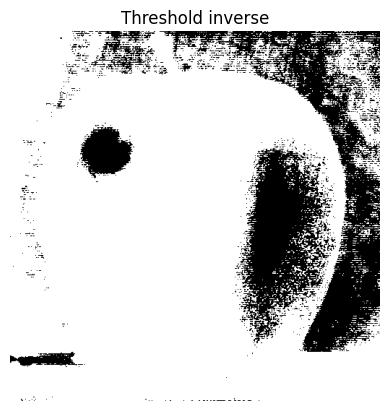

In [15]:
# thresholded inverse

threshold,thresh_inv = cv.threshold(gray,150,255,cv.THRESH_BINARY_INV)

plt.imshow(thresh_inv,cmap="gray")
plt.title("Threshold inverse")
plt.axis("off")
plt.show()

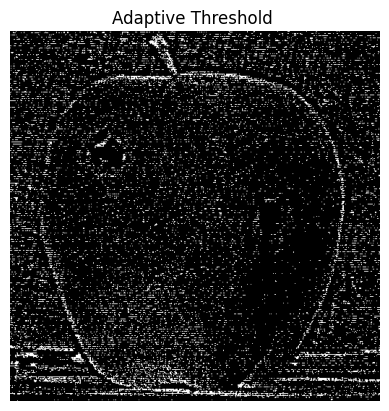

In [20]:
# Adaptive Thresholding : Threshold is mean of neighbourhood area

adaptive_thresh=cv.adaptiveThreshold(gray,255, cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY_INV,11,9)
plt.imshow(adaptive_thresh,cmap="gray")
plt.title("Adaptive Threshold ")
plt.axis("off")
plt.show()

```python
adaptive_thresh = cv.adaptiveThreshold(
    gray, 255,
    cv.ADAPTIVE_THRESH_MEAN_C,
    cv.THRESH_BINARY_INV,
    11, 3
)
```

| Parameter | Value | Description |
|------------|--------|-------------|
| `src` | `gray` | Input grayscale image. |
| `maxValue` | `255` | Pixel value assigned to white pixels after thresholding. |
| `adaptiveMethod` | `cv.ADAPTIVE_THRESH_MEAN_C` | Uses the mean intensity of the local neighborhood as the threshold. |
| `thresholdType` | `cv.THRESH_BINARY_INV` | Pixels above the threshold become black (`0`), others become white (`255`). |
| `blockSize` | `11` | Size of the local neighborhood (must be odd). Larger values consider a wider area. |
| `C` | `3` | Constant subtracted from the computed local threshold. Helps fine-tune sensitivity. |
```